In [ ]:
from pathlib import Path
from collections import defaultdict
import ipaddress
import json
import os

import matplotlib.pyplot as plt
import pandas as pd
import requests
from IPython.display import display

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (11, 6)

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data"
OUTPUT_DIR = BASE_DIR / "outputs"

DATA_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

LOG_PATH = DATA_DIR / "eve.json"

VT_API_KEY = ""
USE_MOCK_VT_IF_NO_KEY = True

print(f"Рабочая директория: {BASE_DIR}")
print(f"Путь к логу: {LOG_PATH}")
print(f"Ключ VirusTotal задан: {'да' if VT_API_KEY else 'нет'}")

Рабочая директория: c:\Users\Dmitriy\Desktop\studies_hse\Программирование Python\Итоговое_ДЗ
Путь к логу: c:\Users\Dmitriy\Desktop\studies_hse\Программирование Python\Итоговое_ДЗ\data\eve.json
Ключ VirusTotal задан: да


In [22]:
demo_events = [
    {"timestamp": "2026-03-09T10:00:01.000000+0300", "event_type": "alert", "src_ip": "185.220.101.10", "dest_ip": "10.0.0.15",
     "alert": {"signature": "ET TROJAN Possible C2 Beacon", "category": "Trojan Activity", "severity": 1}},
    {"timestamp": "2026-03-09T10:00:10.000000+0300", "event_type": "alert", "src_ip": "185.220.101.10", "dest_ip": "10.0.0.15",
     "alert": {"signature": "ET MALWARE Known Malicious IP", "category": "Malware Command and Control Activity Detected", "severity": 1}},
    {"timestamp": "2026-03-09T10:01:01.000000+0300", "event_type": "alert", "src_ip": "45.9.148.201", "dest_ip": "10.0.0.25",
     "alert": {"signature": "ET SCAN Suspicious inbound connection", "category": "Attempted Information Leak", "severity": 2}},
    {"timestamp": "2026-03-09T10:01:30.000000+0300", "event_type": "alert", "src_ip": "45.9.148.201", "dest_ip": "10.0.0.25",
     "alert": {"signature": "ET POLICY External Remote Access Tool", "category": "Potentially Bad Traffic", "severity": 2}},
    {"timestamp": "2026-03-09T10:02:01.000000+0300", "event_type": "alert", "src_ip": "91.240.118.172", "dest_ip": "10.0.0.30",
     "alert": {"signature": "ET TROJAN Downloader Activity", "category": "Malware Command and Control Activity Detected", "severity": 1}},
    {"timestamp": "2026-03-09T10:02:30.000000+0300", "event_type": "dns", "src_ip": "10.0.0.15", "dest_ip": "8.8.8.8",
     "dns": {"rrname": "cdn-update-check.net", "type": "query", "rcode": "NOERROR"}},
    {"timestamp": "2026-03-09T10:02:31.000000+0300", "event_type": "dns", "src_ip": "10.0.0.15", "dest_ip": "8.8.8.8",
     "dns": {"rrname": "cdn-update-check.net", "type": "query", "rcode": "NOERROR"}},
    {"timestamp": "2026-03-09T10:02:32.000000+0300", "event_type": "dns", "src_ip": "10.0.0.15", "dest_ip": "8.8.8.8",
     "dns": {"rrname": "cdn-update-check.net", "type": "query", "rcode": "NOERROR"}},
    {"timestamp": "2026-03-09T10:02:33.000000+0300", "event_type": "dns", "src_ip": "10.0.0.15", "dest_ip": "8.8.8.8",
     "dns": {"rrname": "panel-sync-service.net", "type": "query", "rcode": "NOERROR"}},
    {"timestamp": "2026-03-09T10:02:34.000000+0300", "event_type": "dns", "src_ip": "10.0.0.15", "dest_ip": "8.8.8.8",
     "dns": {"rrname": "panel-sync-service.net", "type": "query", "rcode": "NOERROR"}},
    {"timestamp": "2026-03-09T10:02:35.000000+0300", "event_type": "dns", "src_ip": "10.0.0.15", "dest_ip": "8.8.8.8",
     "dns": {"rrname": "panel-sync-service.net", "type": "query", "rcode": "NOERROR"}},
    {"timestamp": "2026-03-09T10:03:01.000000+0300", "event_type": "dns", "src_ip": "10.0.0.25", "dest_ip": "1.1.1.1",
     "dns": {"rrname": "example.org", "type": "query", "rcode": "NOERROR"}},
    {"timestamp": "2026-03-09T10:03:10.000000+0300", "event_type": "dns", "src_ip": "10.0.0.25", "dest_ip": "1.1.1.1",
     "dns": {"rrname": "example.org", "type": "query", "rcode": "NOERROR"}},
    {"timestamp": "2026-03-09T10:03:20.000000+0300", "event_type": "dns", "src_ip": "10.0.0.50", "dest_ip": "8.8.4.4",
     "dns": {"rrname": "safe-site.local", "type": "query", "rcode": "NOERROR"}},
    {"timestamp": "2026-03-09T10:04:00.000000+0300", "event_type": "flow", "src_ip": "10.0.0.15", "dest_ip": "185.220.101.10",
     "proto": "TCP"},
    {"timestamp": "2026-03-09T10:04:10.000000+0300", "event_type": "flow", "src_ip": "10.0.0.25", "dest_ip": "45.9.148.201",
     "proto": "TCP"},
    {"timestamp": "2026-03-09T10:04:20.000000+0300", "event_type": "flow", "src_ip": "10.0.0.30", "dest_ip": "91.240.118.172",
     "proto": "TCP"}
]

if not LOG_PATH.exists():
    with open(LOG_PATH, "w", encoding="utf-8") as f:
        for event in demo_events:
            f.write(json.dumps(event, ensure_ascii=False) + "\n")
    print(f"Создан демонстрационный лог: {LOG_PATH}")
else:
    print(f"Используется существующий лог: {LOG_PATH}")

Используется существующий лог: c:\Users\Dmitriy\Desktop\studies_hse\Программирование Python\Итоговое_ДЗ\data\eve.json


In [23]:
records = []
with open(LOG_PATH, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        records.append(json.loads(line))

events_df = pd.DataFrame(records)
print(f"Всего событий: {len(events_df)}")
display(events_df.head(10))

Всего событий: 17


,timestamp,event_type,src_ip,dest_ip,alert,dns,proto
0,2026-03-09T10:00:01.000000+0300,alert,185.220.101.10,10.0.0.15,"{'signature': 'ET TROJAN Possible C2 Beacon', ...",NaN,NaN
1,2026-03-09T10:00:10.000000+0300,alert,185.220.101.10,10.0.0.15,"{'signature': 'ET MALWARE Known Malicious IP',...",NaN,NaN
2,2026-03-09T10:01:01.000000+0300,alert,45.9.148.201,10.0.0.25,{'signature': 'ET SCAN Suspicious inbound conn...,NaN,NaN
3,2026-03-09T10:01:30.000000+0300,alert,45.9.148.201,10.0.0.25,{'signature': 'ET POLICY External Remote Acces...,NaN,NaN
4,2026-03-09T10:02:01.000000+0300,alert,91.240.118.172,10.0.0.30,"{'signature': 'ET TROJAN Downloader Activity',...",NaN,NaN
5,2026-03-09T10:02:30.000000+0300,dns,10.0.0.15,8.8.8.8,NaN,"{'rrname': 'cdn-update-check.net', 'type': 'qu...",NaN
6,2026-03-09T10:02:31.000000+0300,dns,10.0.0.15,8.8.8.8,NaN,"{'rrname': 'cdn-update-check.net', 'type': 'qu...",NaN
7,2026-03-09T10:02:32.000000+0300,dns,10.0.0.15,8.8.8.8,NaN,"{'rrname': 'cdn-update-check.net', 'type': 'qu...",NaN
8,2026-03-09T10:02:33.000000+0300,dns,10.0.0.15,8.8.8.8,NaN,"{'rrname': 'panel-sync-service.net', 'type': '...",NaN
9,2026-03-09T10:02:34.000000+0300,dns,10.0.0.15,8.8.8.8,NaN,"{'rrname': 'panel-sync-service.net', 'type': '...",NaN


In [24]:
def safe_get(dct, *keys, default=None):
    current = dct
    for key in keys:
        if not isinstance(current, dict):
            return default
        current = current.get(key)
        if current is None:
            return default
    return current

parsed_rows = []
for row in records:
    parsed_rows.append({
        "timestamp": row.get("timestamp"),
        "event_type": row.get("event_type"),
        "src_ip": row.get("src_ip"),
        "dest_ip": row.get("dest_ip"),
        "alert_signature": safe_get(row, "alert", "signature"),
        "alert_category": safe_get(row, "alert", "category"),
        "alert_severity": safe_get(row, "alert", "severity"),
        "dns_rrname": safe_get(row, "dns", "rrname"),
        "dns_rcode": safe_get(row, "dns", "rcode"),
        "proto": row.get("proto"),
    })

parsed_df = pd.DataFrame(parsed_rows)
display(parsed_df.head(10))

,timestamp,event_type,src_ip,dest_ip,alert_signature,alert_category,alert_severity,dns_rrname,dns_rcode,proto
0,2026-03-09T10:00:01.000000+0300,alert,185.220.101.10,10.0.0.15,ET TROJAN Possible C2 Beacon,Trojan Activity,1.0,None,None,None
1,2026-03-09T10:00:10.000000+0300,alert,185.220.101.10,10.0.0.15,ET MALWARE Known Malicious IP,Malware Command and Control Activity Detected,1.0,None,None,None
2,2026-03-09T10:01:01.000000+0300,alert,45.9.148.201,10.0.0.25,ET SCAN Suspicious inbound connection,Attempted Information Leak,2.0,None,None,None
3,2026-03-09T10:01:30.000000+0300,alert,45.9.148.201,10.0.0.25,ET POLICY External Remote Access Tool,Potentially Bad Traffic,2.0,None,None,None
4,2026-03-09T10:02:01.000000+0300,alert,91.240.118.172,10.0.0.30,ET TROJAN Downloader Activity,Malware Command and Control Activity Detected,1.0,None,None,None
5,2026-03-09T10:02:30.000000+0300,dns,10.0.0.15,8.8.8.8,None,None,NaN,cdn-update-check.net,NOERROR,None
6,2026-03-09T10:02:31.000000+0300,dns,10.0.0.15,8.8.8.8,None,None,NaN,cdn-update-check.net,NOERROR,None
7,2026-03-09T10:02:32.000000+0300,dns,10.0.0.15,8.8.8.8,None,None,NaN,cdn-update-check.net,NOERROR,None
8,2026-03-09T10:02:33.000000+0300,dns,10.0.0.15,8.8.8.8,None,None,NaN,panel-sync-service.net,NOERROR,None
9,2026-03-09T10:02:34.000000+0300,dns,10.0.0.15,8.8.8.8,None,None,NaN,panel-sync-service.net,NOERROR,None


In [25]:
def is_public_ip(value):
    try:
        ip = ipaddress.ip_address(value)
        return ip.is_global
    except ValueError:
        return False

def choose_external_ip(src_ip, dest_ip):
    if is_public_ip(src_ip):
        return src_ip
    if is_public_ip(dest_ip):
        return dest_ip
    if src_ip and not ipaddress.ip_address(src_ip).is_private:
        return src_ip
    if dest_ip and not ipaddress.ip_address(dest_ip).is_private:
        return dest_ip
    return src_ip or dest_ip

alerts_df = parsed_df[parsed_df["event_type"] == "alert"].copy()
alerts_df["indicator"] = alerts_df.apply(lambda x: choose_external_ip(x["src_ip"], x["dest_ip"]), axis=1)

ip_alerts = (
    alerts_df.groupby("indicator", dropna=False)
    .agg(
        alert_count=("indicator", "size"),
        high_severity_alerts=("alert_severity", lambda s: int((pd.to_numeric(s, errors="coerce") <= 2).sum())),
        signatures=("alert_signature", lambda s: "; ".join(sorted(set([str(x) for x in s.dropna()])))),
        categories=("alert_category", lambda s: "; ".join(sorted(set([str(x) for x in s.dropna()])))),
    )
    .reset_index()
)
ip_alerts["indicator_type"] = "public_ip"

dns_df = parsed_df[parsed_df["event_type"] == "dns"].copy()
dns_by_host = (
    dns_df.groupby("src_ip", dropna=False)
    .agg(
        dns_queries=("src_ip", "size"),
        unique_domains=("dns_rrname", lambda s: s.dropna().nunique()),
        domains=("dns_rrname", lambda s: "; ".join(sorted(set([str(x) for x in s.dropna()])))),
    )
    .reset_index()
    .rename(columns={"src_ip": "indicator"})
)
dns_by_host["indicator_type"] = "host"

dns_threshold = 4
unique_domain_threshold = 2

dns_anomalies = dns_by_host[
    (dns_by_host["dns_queries"] >= dns_threshold) |
    (dns_by_host["unique_domains"] >= unique_domain_threshold)
].copy()

print("Подозрительные внешние IP по alert-событиям:")
display(ip_alerts)

print("Хосты с DNS-аномалиями:")
display(dns_anomalies)

Подозрительные внешние IP по alert-событиям:


,indicator,alert_count,high_severity_alerts,signatures,categories,indicator_type
0,185.220.101.10,2,2,ET MALWARE Known Malicious IP; ET TROJAN Possi...,Malware Command and Control Activity Detected;...,public_ip
1,45.9.148.201,2,2,ET POLICY External Remote Access Tool; ET SCAN...,Attempted Information Leak; Potentially Bad Tr...,public_ip
2,91.240.118.172,1,1,ET TROJAN Downloader Activity,Malware Command and Control Activity Detected,public_ip


Хосты с DNS-аномалиями:


,indicator,dns_queries,unique_domains,domains,indicator_type
0,10.0.0.15,6,2,cdn-update-check.net; panel-sync-service.net,host


In [26]:
mock_vt_data = {
    "185.220.101.10": {"vt_malicious": 9, "vt_suspicious": 2, "vt_reputation": -20, "vt_as_owner": "Example ASN", "vt_country": "DE", "vt_source": "mock"},
    "45.9.148.201": {"vt_malicious": 5, "vt_suspicious": 1, "vt_reputation": -10, "vt_as_owner": "Example ASN", "vt_country": "NL", "vt_source": "mock"},
    "91.240.118.172": {"vt_malicious": 7, "vt_suspicious": 1, "vt_reputation": -15, "vt_as_owner": "Example ASN", "vt_country": "UA", "vt_source": "mock"},
}

def get_vt_ip_report(ip):
    if not is_public_ip(ip):
        return {
            "indicator": ip,
            "vt_malicious": 0,
            "vt_suspicious": 0,
            "vt_reputation": 0,
            "vt_as_owner": None,
            "vt_country": None,
            "vt_source": "not_public_ip",
        }

    if VT_API_KEY:
        url = f"https://www.virustotal.com/api/v3/ip_addresses/{ip}"
        headers = {"x-apikey": VT_API_KEY}
        try:
            response = requests.get(url, headers=headers, timeout=30)
            response.raise_for_status()
            payload = response.json()
            attributes = payload.get("data", {}).get("attributes", {})
            stats = attributes.get("last_analysis_stats", {})
            return {
                "indicator": ip,
                "vt_malicious": int(stats.get("malicious", 0)),
                "vt_suspicious": int(stats.get("suspicious", 0)),
                "vt_reputation": int(attributes.get("reputation", 0) or 0),
                "vt_as_owner": attributes.get("as_owner"),
                "vt_country": attributes.get("country"),
                "vt_source": "virustotal_api",
            }
        except Exception as e:
            return {
                "indicator": ip,
                "vt_malicious": 0,
                "vt_suspicious": 0,
                "vt_reputation": 0,
                "vt_as_owner": None,
                "vt_country": None,
                "vt_source": f"api_error: {e}",
            }

    if USE_MOCK_VT_IF_NO_KEY:
        mock = mock_vt_data.get(ip, {})
        return {
            "indicator": ip,
            "vt_malicious": int(mock.get("vt_malicious", 0)),
            "vt_suspicious": int(mock.get("vt_suspicious", 0)),
            "vt_reputation": int(mock.get("vt_reputation", 0)),
            "vt_as_owner": mock.get("vt_as_owner"),
            "vt_country": mock.get("vt_country"),
            "vt_source": mock.get("vt_source", "mock"),
        }

    return {
        "indicator": ip,
        "vt_malicious": 0,
        "vt_suspicious": 0,
        "vt_reputation": 0,
        "vt_as_owner": None,
        "vt_country": None,
        "vt_source": "skipped",
    }

vt_rows = [get_vt_ip_report(ip) for ip in ip_alerts["indicator"].dropna().tolist()]
vt_df = pd.DataFrame(vt_rows)
display(vt_df)

,indicator,vt_malicious,vt_suspicious,vt_reputation,vt_as_owner,vt_country,vt_source
0,185.220.101.10,15,2,-14,Stiftung Erneuerbare Freiheit,DE,virustotal_api
1,45.9.148.201,5,0,0,Nice IT Services Group Inc.,NL,virustotal_api
2,91.240.118.172,12,1,-1,None,HK,virustotal_api


In [27]:
ip_report = ip_alerts.merge(vt_df, on="indicator", how="left")

for col in ["alert_count", "high_severity_alerts", "vt_malicious", "vt_suspicious", "vt_reputation"]:
    if col in ip_report.columns:
        ip_report[col] = pd.to_numeric(ip_report[col], errors="coerce").fillna(0).astype(int)

ip_report["dns_queries"] = 0
ip_report["unique_domains"] = 0
ip_report["domains"] = None

ip_report["risk_score"] = (
    ip_report["alert_count"] * 2
    + ip_report["high_severity_alerts"] * 3
    + ip_report["vt_malicious"] * 2
    + ip_report["vt_suspicious"]
)

ip_report["threat_level"] = pd.cut(
    ip_report["risk_score"],
    bins=[-1, 4, 11, 999],
    labels=["low", "medium", "high"]
)

host_report = dns_anomalies.copy()

for col in ["alert_count", "high_severity_alerts", "vt_malicious", "vt_suspicious", "vt_reputation"]:
    host_report[col] = 0

host_report["vt_as_owner"] = None
host_report["vt_country"] = None
host_report["vt_source"] = "suricata_only"

host_report["risk_score"] = (
    host_report["dns_queries"] * 1
    + host_report["unique_domains"] * 2
)

host_report["threat_level"] = pd.cut(
    host_report["risk_score"],
    bins=[-1, 3, 6, 999],
    labels=["low", "medium", "high"]
)

report_df = pd.concat([ip_report, host_report], ignore_index=True, sort=False)

ordered_columns = [
    "indicator_type", "indicator", "risk_score", "threat_level",
    "alert_count", "high_severity_alerts", "dns_queries", "unique_domains",
    "vt_malicious", "vt_suspicious", "vt_reputation", "vt_country", "vt_as_owner", "vt_source",
    "domains", "signatures", "categories"
]
report_df = report_df[ordered_columns].sort_values(["risk_score", "indicator"], ascending=[False, True]).reset_index(drop=True)

display(report_df)

,indicator_type,indicator,risk_score,threat_level,alert_count,high_severity_alerts,dns_queries,unique_domains,vt_malicious,vt_suspicious,vt_reputation,vt_country,vt_as_owner,vt_source,domains,signatures,categories
0,public_ip,185.220.101.10,42,high,2,2,0,0,15,2,-14,DE,Stiftung Erneuerbare Freiheit,virustotal_api,None,ET MALWARE Known Malicious IP; ET TROJAN Possi...,Malware Command and Control Activity Detected;...
1,public_ip,91.240.118.172,30,high,1,1,0,0,12,1,-1,HK,None,virustotal_api,None,ET TROJAN Downloader Activity,Malware Command and Control Activity Detected
2,public_ip,45.9.148.201,20,high,2,2,0,0,5,0,0,NL,Nice IT Services Group Inc.,virustotal_api,None,ET POLICY External Remote Access Tool; ET SCAN...,Attempted Information Leak; Potentially Bad Tr...
3,host,10.0.0.15,10,high,0,0,6,2,0,0,0,None,None,suricata_only,cdn-update-check.net; panel-sync-service.net,NaN,NaN


In [28]:
def choose_action(row):
    if row["indicator_type"] == "public_ip" and row["risk_score"] >= 12:
        return "BLOCK_IP"
    if row["indicator_type"] == "host" and row["risk_score"] >= 6:
        return "NOTIFY_HOST"
    return "MONITOR"

report_df["action"] = report_df.apply(choose_action, axis=1)

for _, row in report_df.iterrows():
    if row["action"] == "BLOCK_IP":
        print(f"[BLOCK_IP] Имитация блокировки IP {row['indicator']} | score={row['risk_score']} | level={row['threat_level']}")
    elif row["action"] == "NOTIFY_HOST":
        print(f"[NOTIFY_HOST] Подозрительный хост {row['indicator']} | DNS-запросов={row['dns_queries']} | score={row['risk_score']}")
    else:
        print(f"[MONITOR] Индикатор {row['indicator']} оставлен на мониторинг | score={row['risk_score']}")

display(report_df[["indicator_type", "indicator", "risk_score", "threat_level", "action"]])

[BLOCK_IP] Имитация блокировки IP 185.220.101.10 | score=42 | level=high
[BLOCK_IP] Имитация блокировки IP 91.240.118.172 | score=30 | level=high
[BLOCK_IP] Имитация блокировки IP 45.9.148.201 | score=20 | level=high
[NOTIFY_HOST] Подозрительный хост 10.0.0.15 | DNS-запросов=6 | score=10


,indicator_type,indicator,risk_score,threat_level,action
0,public_ip,185.220.101.10,42,high,BLOCK_IP
1,public_ip,91.240.118.172,30,high,BLOCK_IP
2,public_ip,45.9.148.201,20,high,BLOCK_IP
3,host,10.0.0.15,10,high,NOTIFY_HOST


In [29]:
csv_path = OUTPUT_DIR / "threat_report.csv"
json_path = OUTPUT_DIR / "threat_report.json"

report_df.to_csv(csv_path, index=False, encoding="utf-8-sig")
report_df.to_json(json_path, orient="records", force_ascii=False, indent=2)

print(f"CSV сохранён: {csv_path}")
print(f"JSON сохранён: {json_path}")

CSV сохранён: c:\Users\Dmitriy\Desktop\studies_hse\Программирование Python\Итоговое_ДЗ\outputs\threat_report.csv
JSON сохранён: c:\Users\Dmitriy\Desktop\studies_hse\Программирование Python\Итоговое_ДЗ\outputs\threat_report.json


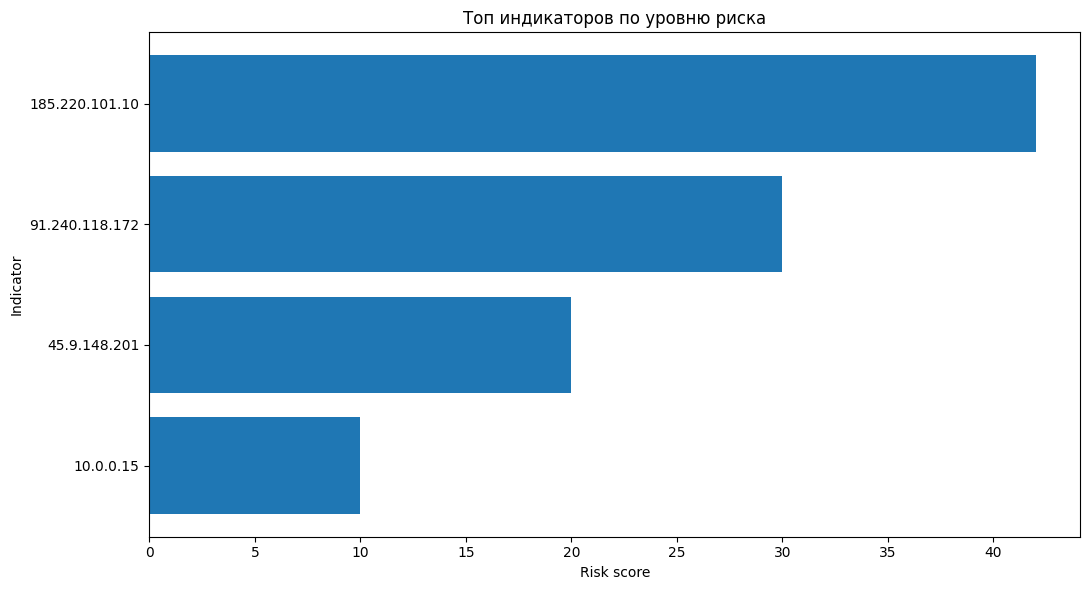

График сохранён: c:\Users\Dmitriy\Desktop\studies_hse\Программирование Python\Итоговое_ДЗ\outputs\threats_top10.png


In [30]:
plot_df = report_df.sort_values("risk_score", ascending=True).tail(10)

plt.figure()
plt.barh(plot_df["indicator"], plot_df["risk_score"])
plt.xlabel("Risk score")
plt.ylabel("Indicator")
plt.title("Топ индикаторов по уровню риска")

plot_path = OUTPUT_DIR / "threats_top10.png"
plt.tight_layout()
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"График сохранён: {plot_path}")